### Yang-Sun's sciript of clusterless decoding with example plot and description.

[1. Specifying your [NWB], ['IntervalList'], and which electrodes involved in the recording to sort data from.](#2)
[`SortGroup`](#SortGroup)

[2. Specifying the parameters to use for filtering the recording.](#4)
[`SpikeSortingPreprocessingParameters`]
<br>
Combining these parameters.
[`SpikeSortingRecordingSelection`]
<br>
Extracting the recording. - [`SpikeSortingRecording`]<br>

[3. Specifying the parameters to apply for artifact detection/removal.](#5)
[`ArtifactDetectionParameters`]<br>

[4. Specify the spike sorter and parameters to use.](#6)
[`SpikeSorterParameters`]
<br>
Combine these parameters. - [`SpikeSortingSelection`]
<br>
Spike sort the extracted recording according to chose parameter set. - [`SpikeSorting`]
<br>

<a href='#section1'></a>
<a href='#section2'></a>


First, we log-in to spyglass and use inserted Session example, **IM-1594_20230726.nwb**

In [ ]:
#  Eric's example decoder notebook for Berke Lab data
# import jax
# import os

# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.99"
# device_id = 1
# device = jax.devices()[device_id]
# jax.config.update("jax_default_device", device)
# device

# # %%
# from spyglass.decoding.v1.sorted_spikes import SortedSpikesDecodingSelection

# selection_key = {
#     "sorted_spikes_group_name": "sorted_spikes_group",
#     "unit_filter_params_name": "default_exclusion",
#     "position_group_name": "sorted_spikes_pos_group",
#     "decoding_param_name": "contfrag_sorted_10chunks_v2",
#     "nwb_file_name": "IM-1478_20220720_.nwb",
#     "encoding_interval": "00_r1",  # to encode using the entire session, this is always our interval list name
#     "decoding_interval": "00_r1",
#     "estimate_decoding_params": True,
# }

# # %%
# from spyglass.decoding import SortedSpikesDecodingV1, DecodingOutput

# SortedSpikesDecodingV1.populate(selection_key)

# # %%

2026-01-19 19:00:15.554958: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 0 and 9; status: INTERNAL: failed to enable peer access from 0x7fb8e49ce6f0 to 0x7fb8d08f8070: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
2026-01-19 19:00:15.571461: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 1 and 9; status: INTERNAL: failed to enable peer access from 0x7fb8d48f82c0 to 0x7fb8d08f8070: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
2026-01-19 19:00:15.573542: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 2 and 9; status: INTERNAL: failed to enable peer access from 0x7fb8e88f8090 to 0x7fb8d08f8070: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
2026-01-19 19:00:15.575269: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_

{'success_count': 0, 'error_list': []}

In [1]:
#before, make sure you are not conflicting with others
#run nvidia-smi on your ssh and determine which GPU you are going to occupy (spyglass can only use one GPU at a time)

import jax
import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.99"
device_id = 7 # or whatever number GPU you want

device = jax.devices()[device_id]
jax.config.update("jax_default_device", device)

# or, check default device again
print("Default device setting:", jax.default_backend())
print("Explicit device you picked:", device)

Default device setting: gpu
Explicit device you picked: gpu:7


2026-02-13 07:24:22.316934: W external/org_tensorflow/tensorflow/compiler/xla/service/platform_util.cc:193] unable to create StreamExecutor for CUDA:9: failed initializing StreamExecutor for CUDA device ordinal 9: INTERNAL: failed call to cuDevicePrimaryCtxRetain: CUDA_ERROR_OUT_OF_MEMORY: out of memory; total memory reported: 84987740160


In [2]:
import os
import datajoint as dj
import numpy as np
import spyglass

print(spyglass.__file__) # confirm your environment is set up correctly
print(spyglass.__version__) # confirm your spyglass version

# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "decoding":
    os.chdir("..")
dj.config["enable_python_native_blobs"] = True
dj.config.load("dj_local_conf.json")  # load config for database connection info

[2026-02-13 07:24:31,865][INFO]: DataJoint 0.14.6 connected to yshwang@lmf-db.cin.ucsf.edu:3306
INFO:datajoint:DataJoint 0.14.6 connected to yshwang@lmf-db.cin.ucsf.edu:3306
[2026-02-13 07:24:32,522][INFO]: DataJoint is configured from /home/yshwang/code/Hex-maze-spyglass/dj_local_conf.json
INFO:datajoint:DataJoint is configured from /home/yshwang/code/Hex-maze-spyglass/dj_local_conf.json


/home/yshwang/code/spyglass/src/spyglass/__init__.py
0.5.5a2.dev28+g2d7bc523c.d20260113


### File and Parameters

In [3]:
import spyglass.common as sgc
import spyglass.spikesorting.v1 as sgs
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
import spyglass.data_import as sgi
import spyglass.position as sgp
from spyglass.common import Nwbfile
from spyglass.spikesorting.v1.recording import SortGroup
from spyglass.decoding.v1.waveform_features import WaveformFeaturesParams
from spyglass.decoding.v1.core import DecodingParameters

nwb_file_name = "IM-1478_20220724.nwb"
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

interval_list_name = "00_r1"
team_name = "Berke Lab and friends"

# parameters
preproc_param_name = "franklab_tetrode_hippocampus"
artifact_param_name = "100uV_frac_07"
sorter = "clusterless_thresholder"
sorter_param_name = "default_clusterless_berke_65uV"
features_param_name = "amplitude_252ch_4clusterless_1" # For UnitWaveformFeatures, sparse = False
waveform_features_group_name = position_group_name = "1000uV_artifact_65uV_detection_custom_channels"
trodes_pos_params_name = "berke_double_led_decoding" # led1_is_front = 0, upsampling_sampling_rate = 500
decoding_param_name = "contfrag_clusterless_50chunks_100block_2halfbin"


# 2. Check parameters

In [5]:
# option for reviewing parameters

review_params = True
if review_params:
    display((sgs.SpikeSortingPreprocessingParameters() & {"preproc_param_name": preproc_param_name}).fetch())

    display((sgs.ArtifactDetectionParameters() & {"artifact_param_name": artifact_param_name}).fetch("artifact_params"))

    display((sgs.SpikeSorterParameters() & {"sorter": sorter, "sorter_param_name": sorter_param_name}).fetch())

    display((WaveformFeaturesParams() & {"features_param_name": features_param_name}).fetch())

    display((sgp.v1.TrodesPosParams() & {"trodes_pos_params_name": trodes_pos_params_name}).fetch1("params"))

    display((DecodingParameters & {"decoding_param_name": decoding_param_name}).fetch('decoding_kwargs'))

    display((DecodingParameters & {"decoding_param_name": decoding_param_name}).fetch('decoding_params'))


array([('franklab_tetrode_hippocampus', {'frequency_min': 600, 'frequency_max': 6000, 'margin_ms': 5, 'seed': 0, 'min_segment_length': 0.0015})],
      dtype=[('preproc_param_name', 'O'), ('preproc_params', 'O')])

array([{'zscore_thresh': None, 'amplitude_thresh_uV': 100, 'proportion_above_thresh': 0.7, 'removal_window_ms': 1.0, 'chunk_duration': '10s', 'n_jobs': 4, 'progress_bar': 'True'}],
      dtype=object)

array([('clusterless_thresholder', 'default_clusterless_berke_65uV', {'detect_threshold': 65.0, 'method': 'locally_exclusive', 'peak_sign': 'neg', 'exclude_sweep_ms': 0.1, 'local_radius_um': 100, 'noise_levels': array([1.]), 'random_chunk_kwargs': {}, 'outputs': 'sorting'})],
      dtype=[('sorter', 'O'), ('sorter_param_name', 'O'), ('sorter_params', 'O')])

array([('amplitude_252ch_4clusterless_1', {'waveform_extraction_params': {'ms_before': 0.5, 'ms_after': 0.5, 'max_spikes_per_unit': None, 'n_jobs': 5, 'total_memory': '5G', 'sparse': False}, 'waveform_features_params': {'amplitude': {'peak_sign': 'neg', 'estimate_peak_time': False}}})],
      dtype=[('features_param_name', 'O'), ('params', 'O')])

{'max_separation': 9.0,
 'max_speed': 300.0,
 'position_smoothing_duration': 0.125,
 'speed_smoothing_std_dev': 0.1,
 'orient_smoothing_std_dev': 0.001,
 'led1_is_front': 0,
 'is_upsampled': 1,
 'upsampling_sampling_rate': 250,
 'upsampling_interpolation_method': 'linear'}

array([{'n_chunks': 50, 'cache_likelihood': False, 'store_log_likelihood': False}],
      dtype=object)

[{'discrete_initial_conditions': array([0.5, 0.5]),
  'continuous_initial_conditions_types': [UniformInitialConditions(),
   UniformInitialConditions()],
  'discrete_transition_concentration': 1.1,
  'discrete_transition_stickiness': array([0., 0.]),
  'discrete_transition_regularization': 1e-10,
  'discrete_transition_type': DiscreteStationaryDiagonal(diagonal_values=array([0.98, 0.98])),
  'continuous_transition_types': [[RandomWalk(environment_name='', movement_var=6.0, movement_mean=0.0, use_manifold_distance=False, direction=None),
    Uniform(environment_name='', environment2_name=None)],
   [Uniform(environment_name='', environment2_name=None),
    Uniform(environment_name='', environment2_name=None)]],
  'environments': [Environment(environment_name='', place_bin_size=2.5, track_graph=None, edge_order=None, edge_spacing=None, is_track_interior=None, position_range=None, infer_track_interior=True, fill_holes=False, dilate=False, bin_count_threshold=0)],
  'infer_track_interior':

In [ ]:
# When merge_ids are needed for waveform features extraction

# from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
# import spyglass.spikesorting.v1 as sgs
# from spyglass.decoding.v1.waveform_features import (
#     UnitWaveformFeaturesSelection,
#     UnitWaveformFeatures,
# )

# We selected 22 shanks with 1-4 channels that have good waveform features for clusterless decoding.
# sort_group_ids = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
# len(sort_group_ids)

# merge_ids = []
# for sort_group_id in sort_group_ids:
#     sorter_keys = {
#         "nwb_file_name": nwb_copy_file_name,
#         "sorter": sorter,
#         "sorter_param_name": sorter_param_name,
#         "artifact_param_name": artifact_param_name,
#         "sort_group_id": sort_group_id,
#     }

#     merge_id = (
#         UnitWaveformFeaturesSelection.proj(merge_id="spikesorting_merge_id")
#         * SpikeSortingOutput.CurationV1
#         * sgs.SpikeSortingSelection
#     ) & SpikeSortingOutput().get_restricted_merge_ids(
#         sorter_keys, sources=["v1"], as_dict=True
#     )
#     display(merge_id)
#     merge_ids.append(merge_id.fetch1("merge_id"))


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
0b808b9a-bea8-961c-e421-e14f88e2299c,amplitude_252ch_4clusterless_1,3eb76e34-5243-41ef-92d1-38a2185b069e,0,63bfdd84-18f4-4e9c-9f7c-773b3308799f,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,10d2305c-2ad6-443d-8762-66e871e26195


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
c94339f0-43f8-a382-482c-955e0600b96c,amplitude_252ch_4clusterless_1,be321a85-98b4-42f2-84fe-8de4068322a0,0,a158a3d1-347e-4b8a-aa3f-1567d0711b83,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,5100c6be-59cb-44ed-88d6-fc49e2dee820


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
56c6230b-61e2-57e8-b31c-130148b27e24,amplitude_252ch_4clusterless_1,74705970-1a61-47b1-9f72-aa9a06a8dc9c,0,74bb0b64-a9a3-45a6-9aac-61c0d045a46b,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,c030c81e-89d6-431a-bfe9-970e70446edc


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
d9a8e3c2-1d7f-b87c-2917-11114d53692d,amplitude_252ch_4clusterless_1,8668b337-4b0b-47ce-9907-fc8f7ff34bb1,0,9e086c52-c39b-415e-90a7-9356f74a4620,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,08df1871-1ad0-467f-a2b8-8caf8ce4ca63


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
c93aca26-84b4-1ab7-1d59-603b9d655973,amplitude_252ch_4clusterless_1,28de5b85-40c4-41e0-803c-5fd3f7e5c06b,0,7de19529-bf69-4996-a71e-f844cdd6fb55,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,ae9ffb2c-b4e8-4231-a161-666b954f51a5


...

merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
81ab0ac0-5df4-de48-adf2-bf45399af881,amplitude_252ch_4clusterless_1,eb775a97-ad30-4cd0-a20c-1e26c2498935,0,32d194fa-cc50-4403-875d-db463f6afe32,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,91c0e32c-c49d-473d-aa8a-a7323f14e700


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
3cfbe388-000e-1208-3f11-bda87072f0b2,amplitude_252ch_4clusterless_1,92bfa078-81b3-41cb-a023-06dbfe5515f2,0,0539b93f-bb2c-47d1-8010-b7eba1f2e443,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,1a01245c-41c9-40c0-89a6-83af98079007


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
f596862f-4af2-d2bb-7a6d-c46ee2da5422,amplitude_252ch_4clusterless_1,519204d8-01a8-49dd-bcf5-460f5ed716f1,0,af61a8f2-dce6-4db4-86cb-0366c415ef40,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,5afd2fe6-64bc-4130-8951-fc4737df56ea


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
ab23a5d3-22b7-b891-0f6e-1a020e67f28d,amplitude_252ch_4clusterless_1,c1bf1236-43fa-4edb-b273-a2a7cbbfed68,0,6bc95c84-9379-498a-b6a0-aedc6a50a534,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,2a888c21-fee6-43e7-b921-b59c8a1b12c1


merge_id,features_param_name a name for this set of parameters,sorting_id,curation_id,recording_id,sorter,sorter_param_name,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list
c8522e32-a963-d159-1ffb-72d7179a2cbb,amplitude_252ch_4clusterless_1,ab1852f6-f95e-4240-9345-e1d7fc562a3d,0,67f3b315-9a5a-46aa-a399-a6157515c17f,clusterless_thresholder,default_clusterless_berke_75uV,IM-1478_20220724_.nwb,27241d42-a538-4b4b-aa01-9cde5d4c05dd


In [ ]:
from non_local_detector.models import ContFragClusterlessClassifier
from spyglass.decoding.v1.core import DecodingParameters

if False:
    #decoding_param_name = "contfrag_clusterless_50chunks_100block_2halfbin"
    s
    #ContFragClusterlessClassifier(
    #    clusterless_algorithm_params={
    #        "block_size": 2000,
    #        "position_std": 6.0,
    #        "waveform_std": 24.0,
    #    },
    #)
    
    # when I was trying to change the bin size
    # row = (DecodingParameters & {"decoding_param_name": "contfrag_clusterless_252ch_4chunks_2000blocks"}).fetch1()
    # p = row["decoding_params"]["environments"]
    # p[0].place_bin_size = 2.5
    # print(row)
    
    DecodingParameters.insert1(
        {
            "decoding_param_name": decoding_param_name,
            "decoding_params": ContFragClusterlessClassifier(
                                #environments = row["decoding_params"]["environments"],
                                clusterless_algorithm_params={
                                "block_size": 100,
                                "position_std": 6.0,
                                "waveform_std": 24.0,
                                },
                                ),
            "decoding_kwargs": {
                                "n_chunks": 50,
                                "cache_likelihood": False,
                                "store_log_likelihood": False,
                                },
        },
        skip_duplicates=True,
    )
    
model_params = (
    DecodingParameters & {"decoding_param_name": decoding_param_name }
).fetch1()
display(ContFragClusterlessClassifier(**model_params["decoding_params"]))
display(DecodingParameters & {"decoding_param_name": decoding_param_name })

ContFragClusterlessClassifier(clusterless_algorithm='clusterless_kde',
                              clusterless_algorithm_params={'block_size': 100,
                                                            'position_std': 6.0,
                                                            'waveform_std': 24.0},
                              continuous_initial_conditions_types=[UniformInitialConditions(),
                                                                   UniformInitialConditions()],
                              continuous_transition_types=[[RandomWalk(environment_name='',
                                                                       movement_var=6.0,
                                                                       movement_mean=0.0,
                                                                       use_m...
                                                        fill_holes=False,
                                                        dilate=False,
                                                        bin_count_threshold=0)],
                              infer_track_interior=True, no_spike_rate=1e-10,
                              observation_models=[ObservationModel(environment_name='',
                                                                   encoding_group=0,
                                                                   is_local=False,
                                                                   is_no_spike=False),
                                                  ObservationModel(environment_name='',
                                                                   encoding_group=0,
                                                                   is_local=False,
                                                                   is_no_spike=False)],
                              sampling_frequency=500.0,
                              state_names=['Continuous', 'Fragmented'])

decoding_param_name a name for this set of parameters,decoding_params initialization parameters for model,decoding_kwargs additional keyword arguments
contfrag_clusterless_50chunks_100block_2halfbin,=BLOB=,=BLOB=


### Selection key for decoder output

In [4]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingSelection
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1

ClusterlessDecodingSelection & {"nwb_file_name": nwb_copy_file_name}
#DecodingOutput.ClusterlessDecodingV1 & {"nwb_file_name": nwb_copy_file_name}

nwb_file_name name of the NWB file,waveform_features_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters


In [11]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingSelection

selection_key = {
    "waveform_features_group_name": waveform_features_group_name,
    "position_group_name": waveform_features_group_name,
    "decoding_param_name": decoding_param_name,
    "nwb_file_name": nwb_copy_file_name,
    "encoding_interval": "00_r1",
    "decoding_interval": "epoch0_block1",
    "estimate_decoding_params": True,
}

# ClusterlessDecodingSelection.insert1(
#     selection_key,
#     skip_duplicates=True,
# )

ClusterlessDecodingSelection & selection_key


nwb_file_name name of the NWB file,waveform_features_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters
IM-1594_20230725_.nwb,1000uV_artifact_65uV_detection_custom_channels,1000uV_artifact_65uV_detection_custom_channels,contfrag_clusterless_50chunks_100block_2halfbin,00_r1,epoch0_block1,1


To run decoding, we simply populate the `ClusterlessDecodingOutput` table. This will run the decoding and insert the results into the database. We can then retrieve the results from the database.

In [12]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1

ClusterlessDecodingV1.populate(selection_key)

[13:42:22][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False
/home/yshwang/code/spyglass/src/spyglass/decoding/v1/core.py:313: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  position_df[column]

Encoding models:   0%|          | 0/25 [00:00<?, ?electrode/s]

Non-Local Likelihood:   0%|          | 0/25 [00:00<?, ?electrode/s]

Non-Local Likelihood:   0%|          | 0/25 [00:00<?, ?electrode/s]

Non-Local Likelihood:   0%|          | 0/25 [00:00<?, ?electrode/s]

...

Non-Local Likelihood:   0%|          | 0/25 [00:00<?, ?electrode/s]

Non-Local Likelihood:   0%|          | 0/25 [00:00<?, ?electrode/s]

Non-Local Likelihood:   0%|          | 0/25 [00:00<?, ?electrode/s]

/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/non_local_detector/models/base.py:1126: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'state_bins' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  results = xr.Dataset(
/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, b

{'success_count': 1, 'error_list': []}

### Figurl

In [13]:
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1
from non_local_detector.visualization import (
    create_interactive_2D_decoding_figurl,
)


decoding_results = (ClusterlessDecodingV1 & selection_key).fetch_results()

(
    position_info,
    position_variable_names,
) = ClusterlessDecodingV1.fetch_position_info(selection_key)

results_time = decoding_results.acausal_posterior.time.values
position_info = position_info.loc[results_time[0] : results_time[-1]]

env = ClusterlessDecodingV1.fetch_environments(selection_key)[0]
spike_times, _ = ClusterlessDecodingV1.fetch_spike_data(selection_key)


create_interactive_2D_decoding_figurl(
    position_time=position_info.index.to_numpy(),
    position=position_info[position_variable_names],
    env=env,
    results=decoding_results,
    posterior=decoding_results.acausal_posterior
    .unstack("state_bins")
    .sum("state"),
    spike_times=spike_times,
    head_dir=position_info["orientation"],
    speed=position_info["speed"],
)

[2026-01-24 17:33:58,452][WARNING]: Skipped checksum for file with hash: 567fd26b-3c6f-3aca-d05d-c2b72affa667, and path: /stelmo/nwb/analysis/IM-1594_20230725/IM-1594_20230725_390169f4-9d95-4433-a3e8-fd461810f680.nc
/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  warnings.warn(
/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than onc

Computing sha1 of /stelmo/nwb/kachery_storage/tmp_2gdfsx9n/file.dat


'https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=sha1://6b20819a00a65b2e456c892ba11765df23eefa55&label=2D%20Decoding&zone=franklab.default'

### 1. Position heatmap

In [ ]:
from spyglass.position import PositionOutput

# firstm, find merge id from TrodesPosSelection


trodes_s_key = {
    "nwb_file_name": nwb_copy_file_name,
    "interval_list_name": "pos 0 valid times",
    "trodes_pos_params_name": trodes_pos_params_name,
}

PositionOutput.TrodesPosV1 & trodes_s_key

merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
d931de2e-09f2-de2c-2c9b-8fc8f54eb3d1,IM-1478_20220725_.nwb,pos 0 valid times,berke_double_led_decoding


In [56]:
PositionOutput.TrodesPosV1 & {"nwb_file_name": nwb_copy_file_name}

merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
8e84f148-f8e9-753d-f896-73b6df291122,IM-1478_20220724_.nwb,pos 0 valid times,berke_double_led
d519fce6-e4b7-eebc-7508-2176f6857bbb,IM-1478_20220724_.nwb,pos 0 valid times,berke_double_led_500
ec5c50ef-3814-5802-cc56-c1154cad22dd,IM-1478_20220724_.nwb,pos 0 valid times,berke_double_led_decoding


merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
b8f5b7ed-dcc4-9ab5-38cc-7c6e67e2c09a,IM-1594_20230725_.nwb,pos 0 valid times,berke_double_led_decoding


[15:25:34][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False


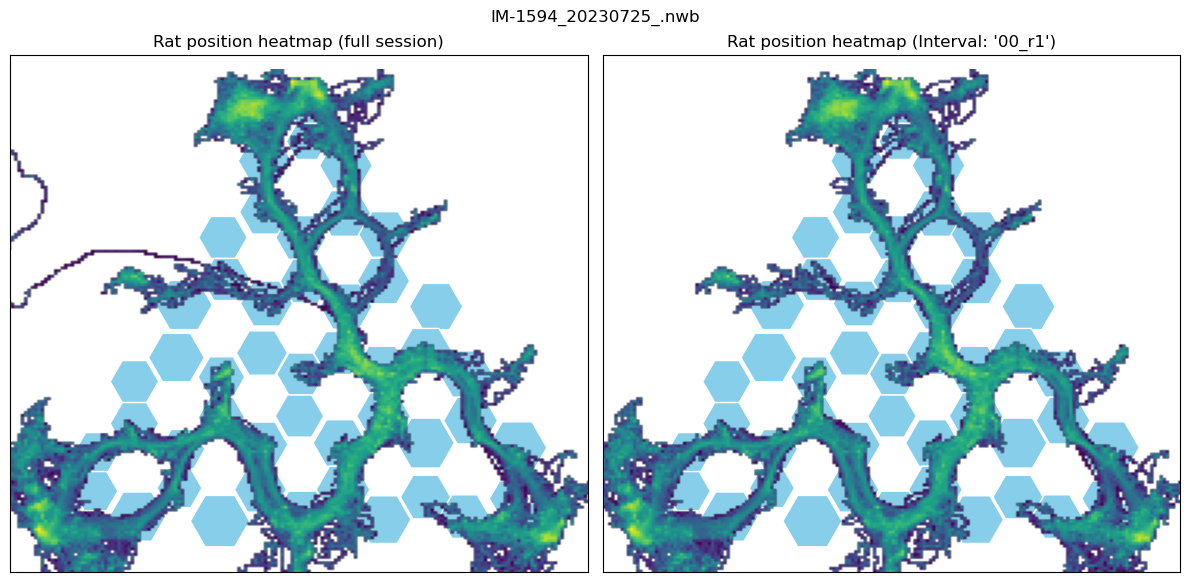

In [3]:
from spyglass.position import PositionOutput
from hex_maze_behavior import HexMazeBlock, HexCentroids
from hexmaze import plot_hex_maze
import matplotlib.pyplot as plt
import numpy as np

# Grab a key from the output above for now
# Use this merge id to restrict the PositionOutput table and fetch the position data
nwb_copy_file_name = 'IM-1594_20230725_.nwb'
interval_list_name = '00_r1'
trodes_pos_params_name = "berke_double_led_decoding"

trodes_s_key = {
    "nwb_file_name": nwb_copy_file_name,
    "interval_list_name": "pos 0 valid times",
    "trodes_pos_params_name": trodes_pos_params_name,
}

display(PositionOutput.TrodesPosV1 & trodes_s_key)

key = {
    'nwb_file_name': nwb_copy_file_name, 
    'merge_id': str((PositionOutput.TrodesPosV1 & trodes_s_key).fetch1('merge_id'))
}


# Fetch processed position data for this epoch (remove nan)
position_df = (PositionOutput & key).fetch1_dataframe()
position_df = position_df.dropna(subset=['position_x', 'position_y'])

# Restrict the position data to '00_r1' interval
valid_times = (sgc.IntervalList() & {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': interval_list_name}).fetch1('valid_times')[0]
position_df_interval = position_df.loc[(position_df.index >= valid_times[0]) & (position_df.index <= valid_times[1])]

# Get the hex centroids for this session for plotting the hexes in the right places
centroids_dict = HexCentroids().get_hex_centroids_dict_cm(key)
# Remove side hex centroids (plotting expects exactly 49 integer centroids)
centroids_dict = {int(k): v for k, v in centroids_dict.items() if "_left" not in k and "_right" not in k}

# Plot rat position heatmap for the full epoch
fig_full, ax_full = plt.subplots(1, 2, figsize=(12, 6))

# Full Session: Create 2D histogram (aka heatmap) of the rat's x, y positions
heatmap_full, xedges, yedges = np.histogram2d(
    position_df['position_x'].values, position_df['position_y'].values, bins=200
)
heatmap_full_masked = np.ma.masked_where(heatmap_full == 0, heatmap_full)
log_heatmap_full = np.log1p(heatmap_full_masked)

# Plot maze layout (open hexes only) using custom centroids if they exist
if centroids_dict is not None:
    plot_hex_maze(
        barriers=None, centroids=centroids_dict, ax=ax_full[0], show_hex_labels=False,
        show_barriers=False, show_choice_points=False, invert_yaxis=True
    )
# Plot rat position heatmap on top of the hexes
ax_full[0].imshow(
    log_heatmap_full.T, origin='lower', cmap='viridis',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='equal', zorder=1
)
ax_full[0].set_xticks([])
ax_full[0].set_yticks([])
ax_full[0].set_title(f"Rat position heatmap (full session)")

# Interval Session: Create 2D histogram (aka heatmap) of the rat's x, y positions
heatmap_interval, xedges_interval, yedges_interval = np.histogram2d(
    position_df_interval['position_x'].values, position_df_interval['position_y'].values, bins=200
)
heatmap_interval_masked = np.ma.masked_where(heatmap_interval == 0, heatmap_interval)
log_heatmap_interval = np.log1p(heatmap_interval_masked)

if centroids_dict is not None:
    plot_hex_maze(
        barriers=None, centroids=centroids_dict, ax=ax_full[1], show_hex_labels=False,
        show_barriers=False, show_choice_points=False, invert_yaxis=True
    )
ax_full[1].imshow(
    log_heatmap_interval.T, origin='lower', cmap='viridis',
    extent=[xedges_interval[0], xedges_interval[-1], yedges_interval[0], yedges_interval[-1]],
    aspect='equal', zorder=1
)
ax_full[1].set_xticks([])
ax_full[1].set_yticks([])
ax_full[1].set_title(f"Rat position heatmap (Interval: '{interval_list_name}')")

fig_full.suptitle(nwb_copy_file_name)
fig_full.tight_layout()
fig_full.show()

In [12]:
DecodingOutput.ClusterlessDecodingV1 & selection_key
DecodingOutput.ClusterlessDecodingV1 & {'decoding_interval': 'epoch0_block1'}

merge_id,nwb_file_name name of the NWB file,waveform_features_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters
283b3c6a-a51c-1369-6624-2185c169a39d,IM-1478_20220724_.nwb,1000uV_artifact_75uV_detection_custom_channels,1000uV_artifact_75uV_detection_custom_channels,contfrag_clusterless_40chunks_500block_3bin,00_r1,epoch0_block1,1
4e1f4ceb-11b5-837c-16a8-e0ac5b49471b,IM-1478_20220725_.nwb,1000uV_artifact_75uV_detection_custom_channels,1000uV_artifact_75uV_detection_custom_channels,contfrag_clusterless_40chunks_500block_3bin,00_r1,epoch0_block1,1
576a94e6-871e-87a2-7b33-d684d79853cc,IM-1871_20250801_.nwb,ampl1000_amplitude_500uV,ampl1000_amplitude_500uV,contfrag_clusterless_252ch_4chunks_2000block_3bin,epoch0_block1,epoch0_block1,1


### Figurl Generator

In [14]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingSelection
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1
from non_local_detector.visualization import (
    create_interactive_2D_decoding_figurl,
)

selection_key = {
    "waveform_features_group_name": waveform_features_group_name,
    "position_group_name": waveform_features_group_name,
    "decoding_param_name": decoding_param_name,
    "nwb_file_name": "IM-1478_20220724_.nwb",
    "encoding_interval": "00_r1",
    "decoding_interval": "epoch0_block1",
    "estimate_decoding_params": True,
}

display(ClusterlessDecodingSelection & selection_key)


decoding_results = (ClusterlessDecodingV1 & selection_key).fetch_results()
(
    position_info,
    position_variable_names,
) = ClusterlessDecodingV1.fetch_position_info(selection_key)

results_time = decoding_results.acausal_posterior.time.values
position_info = position_info.loc[results_time[0] : results_time[-1]]

env = ClusterlessDecodingV1.fetch_environments(selection_key)[0]
spike_times, _ = ClusterlessDecodingV1.fetch_spike_data(selection_key)

create_interactive_2D_decoding_figurl(
    position_time=position_info.index.to_numpy(),
    position=position_info[position_variable_names],
    env=env,
    results=decoding_results,
    posterior=decoding_results.acausal_posterior
    .unstack("state_bins")
    .sum("state"),
    spike_times=spike_times,
    head_dir=position_info["orientation"],
    speed=position_info["speed"],
)

nwb_file_name name of the NWB file,waveform_features_group_name,position_group_name,decoding_param_name a name for this set of parameters,encoding_interval descriptive name of this interval list,decoding_interval descriptive name of this interval list,estimate_decoding_params whether to estimate the decoding parameters
IM-1478_20220724_.nwb,1000uV_artifact_75uV_detection_custom_channels,1000uV_artifact_75uV_detection_custom_channels,contfrag_clusterless_40chunks_500block_3bin,00_r1,epoch0_block1,1


[2026-01-19 17:32:25,221][WARNING]: Skipped checksum for file with hash: 876fb688-59d1-0141-bbbc-6e5ad792d1a7, and path: /stelmo/nwb/analysis/IM-1478_20220724/IM-1478_20220724_54f63b25-27ea-49de-9a5d-7f1e14ce4bb2.nc
/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  warnings.warn(
/home/yshwang/miniforge3/envs/spyglass/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than onc

Computing sha1 of /stelmo/nwb/kachery_storage/tmp_NqKLaGW9/file.dat


'https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=sha1://589b04c1448cbb2489dd7345a1af359256907458&label=2D%20Decoding&zone=franklab.default'